In [5]:
import polars as pl
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

In [22]:
items = pl.read_parquet("../data/items.parquet")

In [ ]:
transactions = pl.read_parquet("../data/transactions-2025-12.parquet")

In [24]:
items = items.filter(pl.col("sale_status")==1)
items.head()

item_id,price,category_l1,category_l2,category_l3,category,brand,manufacturer,description,sale_status,size
str,"decimal[38,4]",str,str,str,str,str,str,str,i32,str
"""0006030000027""",450000.0000,"""Hóa mỹ phẩm gia đình""","""Chăm sóc mẹ trước & sau sinh""","""Chăm sóc da""","""Kem rạn da Palmer's""","""Palmer""","""Không xác định""","""﻿Chi tiết sản phẩm: Giúp ngăn …",1,"""Không xác định"""
"""0502100340019""",75000.0000,"""Babycare""","""Đồ dùng vệ sinh""","""Vệ sinh cơ thể""","""Vệ sinh móng""","""KUKU""","""Không xác định""","""Thông tin sản phẩm: Chất liệu …",1,"""Không xác định"""
"""0007080000262""",65000.0000,"""Hóa mỹ phẩm cho bé""","""Vệ sinh cho bé""","""Kem đánh răng""","""Kem đánh răng Kuku""","""KUKU""","""Không xác định""","""Kem đánh răng Kuku sử dụng xyl…",1,"""Không xác định"""
"""0502040340038""",38000.0000,"""Babycare""","""Đồ dùng ăn uống""","""Dụng cụ ăn uống""","""Dụng cụ ăn uống Kuku""","""KUKU""","""Không xác định""","""Muỗng Ăn Melamine KuKu KU3006 …",1,"""Không xác định"""
"""0007090000300""",59000.0000,"""Hóa mỹ phẩm cho bé""","""Chăm sóc da bé""","""Phấn rôm & phấn thơm""","""Phấn rôm & phấn thơm Pureen""","""Pureen""","""Không xác định""","""Hướng dẫn sử dụng Dùng miếng b…",1,"""Không xác định"""


In [20]:
# 2. Lọc các mặt hàng có category_l1 là "Tã"
# 3. Sử dụng Regular Expression để tách số lượng từ cột description
# Regex r"(\d+)\s*mi[ếễ]ng": 
#   (\d+) là nhóm bắt giữ các chữ số
#   \s* cho phép có hoặc không có khoảng trắng
#   mi[ếễ]ng để khớp với cả "miếng" và "miễng" (theo ví dụ của bạn)
df_ta = (
    items
    .filter(pl.col("category_l1") == "Tã")
    .with_columns(
        pl.col("description")
        .str.extract(r"(\d+)\s*miếng", 1) # Lấy nhóm số đầu tiên tìm thấy
        .cast(pl.Int64)                     # Chuyển kiểu dữ liệu sang số nguyên
        .alias("pieces")                    # Lưu vào cột mới tên là 'pieces'
    )
)

# Kiểm tra kết quả của một vài dòng đầu tiên
df_ta.select(["item_id", "description", "pieces"]).head()

item_id,description,pieces
str,str,i64
"""0020010000098""","""﻿﻿﻿Bỉm tã quần Merries size M …",58
"""1249000000001""","""﻿﻿Tã dán Moony (S, 84 miếng) đ…",84
"""0020010000094""","""﻿﻿Tã dán Merries size S 82 miế…",82
"""0020010000083""","""Miếng lót Huggies size Newborn…",56
"""0020010000096""","""﻿﻿Tã dán Merries size L 54 miế…",54


In [28]:
size_pattern = r"(?i)(NB|S|M|L|XL|XXL|XXXL|[23]XL)"

# 3. Thực hiện lọc và trích xuất
df_ta_with_size = (
    items
    .filter(pl.col("category_l1") == "Tã") # Chỉ lấy sản phẩm là Tã
    .with_columns(
        pl.col("description")
        .str.extract(size_pattern, 1)        # Trích xuất size từ mô tả
        .str.to_uppercase()                 # Chuẩn hóa về chữ in hoa
        .alias("size")                      # Ghi đè hoặc lưu vào cột size
    )
    .filter(pl.col("size") != "Không xác định")   # Chỉ giữ lại các sản phẩm có thông tin size
)

# 4. Hiển thị kết quả kiểm tra
print(df_ta_with_size.select(["item_id", "category_l1", "category_l2", "category_l3", "category", "size"]).head())

shape: (5, 6)
┌───────────────┬─────────────┬─────────────┬───────────────┬────────────────────────────┬──────┐
│ item_id       ┆ category_l1 ┆ category_l2 ┆ category_l3   ┆ category                   ┆ size │
│ ---           ┆ ---         ┆ ---         ┆ ---           ┆ ---                        ┆ ---  │
│ str           ┆ str         ┆ str         ┆ str           ┆ str                        ┆ str  │
╞═══════════════╪═════════════╪═════════════╪═══════════════╪════════════════════════════╪══════╡
│ 2287000000001 ┆ Tã          ┆ Moony       ┆ Moony Natural ┆ Moony Natural_Tã Quần      ┆ M    │
│ 3266000000004 ┆ Tã          ┆ Caryn       ┆ Caryn         ┆ Caryn_Tã dán               ┆ S    │
│ 0020090000043 ┆ Tã          ┆ Bobby       ┆ Bobby Fresh   ┆ Bobby Fresh_Sơ Sinh        ┆ M    │
│ 2286000000002 ┆ Tã          ┆ Moony       ┆ Moony Natural ┆ Moony Natural_Tã dán M-XXL ┆ M    │
│ 2287000890002 ┆ Tã          ┆ Moony       ┆ Moony         ┆ Moony_Tã Quần              ┆ M    │
└─────

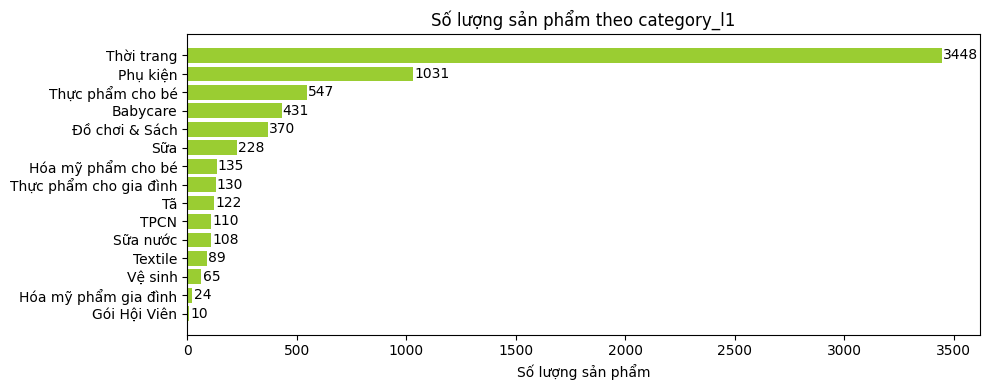

In [14]:
# Nếu dùng pandas:
# df là dataframe chứa dữ liệu
df = items.to_pandas()
count_by_category = df['category_l1'].value_counts().sort_values(ascending=False)

plt.figure(figsize=(10, 4))
bars = plt.barh(count_by_category.index, count_by_category.values, color='yellowgreen')
plt.xlabel('Số lượng sản phẩm')
plt.title('Số lượng sản phẩm theo category_l1')

# Hiển thị số lên từng bar
for bar, value in zip(bars, count_by_category.values):
    plt.text(value + 5, bar.get_y() + bar.get_height()/2, str(value), va='center')

plt.gca().invert_yaxis()  # Để danh mục lớn nhất ở trên
plt.tight_layout()
plt.show()

C:\Users\Minh Nguyen\AppData\Local\Temp\ipykernel_8308\2794017482.py:3: DeprecationWarning: `GroupBy.count` was renamed; use `GroupBy.len` instead
  (pl.col('brand')!='Không xác định') & (pl.col('brand')!='Thương hiệu khác')).group_by('brand').count().sort('count', descending=True).head(15)
C:\Users\Minh Nguyen\AppData\Local\Temp\ipykernel_8308\2794017482.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y='brand', x='count', data=brands_count_pd, palette='viridis')


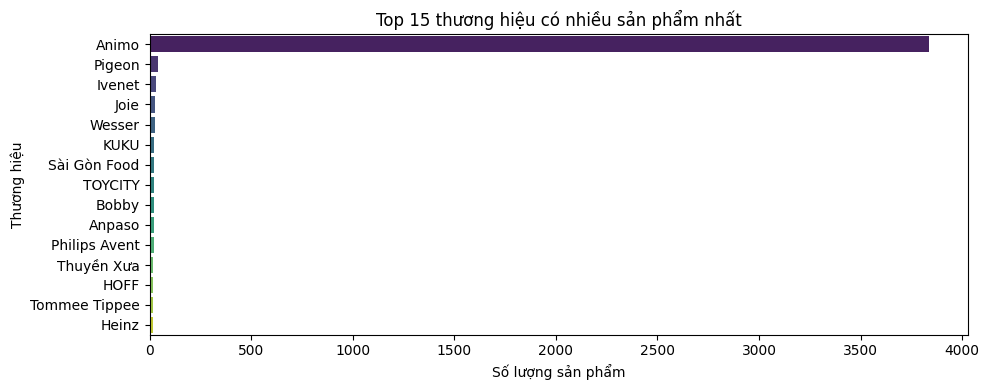

In [15]:
# Lọc bỏ sản phẩm không có brand, đếm số SP theo từng thương hiệu và lấy top 15 bằng Polars, vẽ biểu đồ bằng seaborn
brands_count = items.filter(~pl.col('brand').is_null() & (pl.col('brand') != '') &
                            (pl.col('brand')!='Không xác định') & (pl.col('brand')!='Thương hiệu khác')).group_by('brand').count().sort('count', descending=True).head(15)
brands_count_pd = brands_count.to_pandas()
plt.figure(figsize=(10, 4))
sns.barplot(y='brand', x='count', data=brands_count_pd, palette='viridis')
plt.xlabel('Số lượng sản phẩm')
plt.ylabel('Thương hiệu')
plt.title('Top 15 thương hiệu có nhiều sản phẩm nhất')
plt.tight_layout()
plt.show()

In [17]:
transactions.head(10)

customer_id,item_id,price,channel,payment,updated_date
i32,str,"decimal[38,4]",str,str,datetime[μs]
7853616,"""2406000000005""",585000.0000,"""iOS""","""ShopeePay""",2025-12-01 12:09:11.467
9059471,"""2691000000001""",83720.0000,"""SPE""","""Không xác định""",2025-12-16 12:05:55.600
8751174,"""0199000000003""",139000.0000,"""SPE""","""Tiền mặt""",2025-12-16 11:24:05.667
9090641,"""4950000000002""",385000.0000,"""SPE""","""Tiền mặt""",2025-12-16 12:09:30.447
2554844,"""4680000000002""",45080.0000,"""SPE""","""Không xác định""",2025-12-16 11:11:18.330
8236049,"""2406000000006""",1099000.0000,"""SPE""","""Không xác định""",2025-12-16 12:04:08.627
7955723,"""0041000000028""",407500.0000,"""SPE""","""Tiền mặt""",2025-12-16 11:25:09.480
3015077,"""7350000000003""",21000.0000,"""SPE""","""Không xác định""",2025-12-13 17:11:11.097
3818301,"""6766000000002""",144421.5000,"""SPE""","""Tiền mặt""",2025-12-16 12:14:31.373


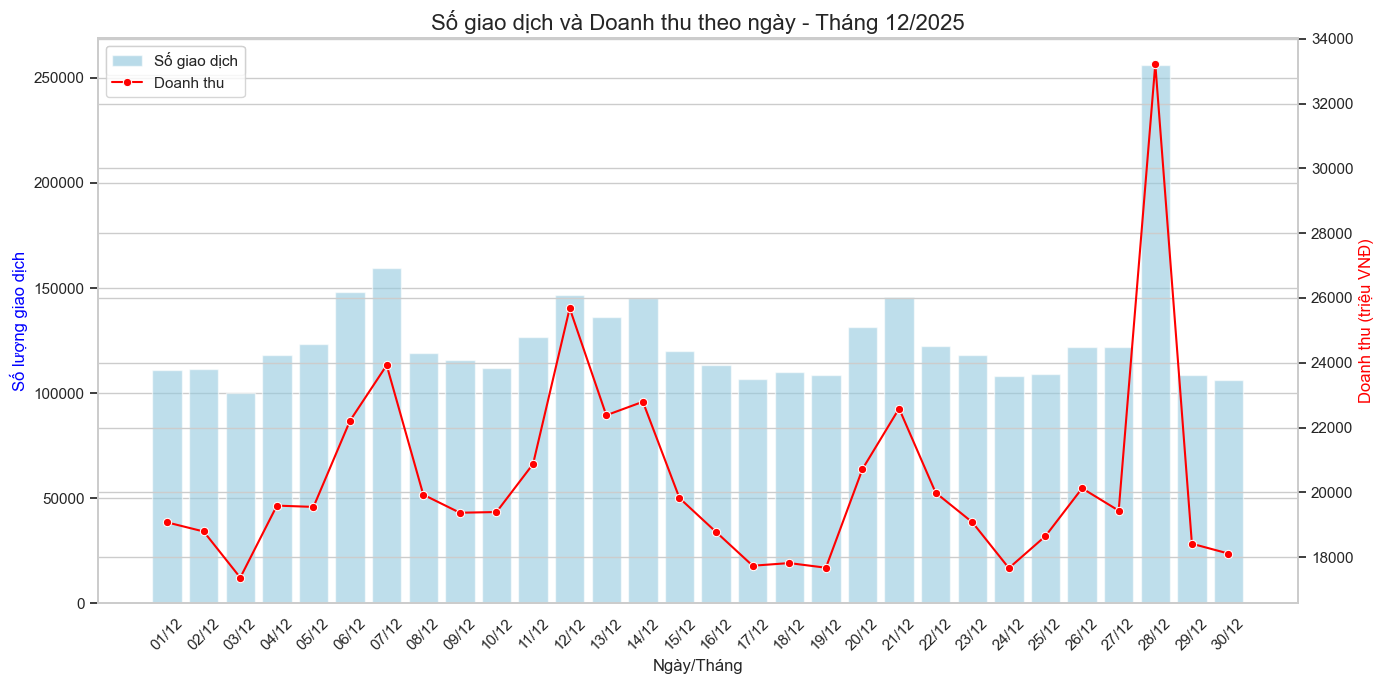

In [9]:
import matplotlib.dates as mdates

daily_summary = (
    transactions
    .with_columns(
        pl.col("updated_date").cast(pl.Datetime).dt.date()
    )
    .group_by("updated_date")
    .agg([
        pl.count("item_id").alias("transaction_count"),
        pl.sum("price").alias("total_revenue")
    ])
    .sort("updated_date")
)

# Chuyển sang Pandas để vẽ
df_plot = daily_summary.to_pandas()
# Quan trọng: Đảm bảo cột ngày là kiểu datetime của Pandas để mdates hoạt động
df_plot["updated_date"] = pd.to_datetime(df_plot["updated_date"])

# Scale doanh thu theo đơn vị triệu đồng
df_plot["total_revenue_million"] = df_plot["total_revenue"] / 1_000_000

# 2. Vẽ biểu đồ
plt.figure(figsize=(14, 7))
sns.set_theme(style="whitegrid")

ax1 = sns.barplot(
    data=df_plot, 
    x="updated_date", 
    y="transaction_count", 
    color="skyblue", 
    alpha=0.6, 
    label="Số giao dịch"
)

ax2 = ax1.twinx()
sns.lineplot(
    data=df_plot, 
    x=ax1.get_xticks(), 
    y="total_revenue_million", 
    color="red", 
    marker="o", 
    ax=ax2, 
    label="Doanh thu"
)

# --- PHẦN ĐỊNH DẠNG LẠI TRỤC HOÀNH ---

# Định dạng hiển thị thành "Ngày/Tháng" (ví dụ: 05/12)
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%d/%m'))

# Đảm bảo hiển thị đầy đủ các ngày (nếu dữ liệu dày đặc có thể dùng mdates.DayLocator())
# Ở đây ta ép Matplotlib dùng chính danh sách ngày trong dữ liệu
ax1.set_xticks(range(len(df_plot)))
ax1.set_xticklabels([d.strftime('%d/%m') for d in df_plot["updated_date"]], rotation=45)

# -------------------------------------

ax1.set_title("Số giao dịch và Doanh thu theo ngày - Tháng 12/2025", fontsize=16)
ax1.set_xlabel("Ngày/Tháng", fontsize=12)
ax1.set_ylabel("Số lượng giao dịch", color="blue")
ax2.set_ylabel("Doanh thu (triệu VNĐ)", color="red")

lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc="upper left")

plt.tight_layout()
plt.show()

C:\Users\Minh Nguyen\AppData\Local\Temp\ipykernel_3980\3868887774.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(


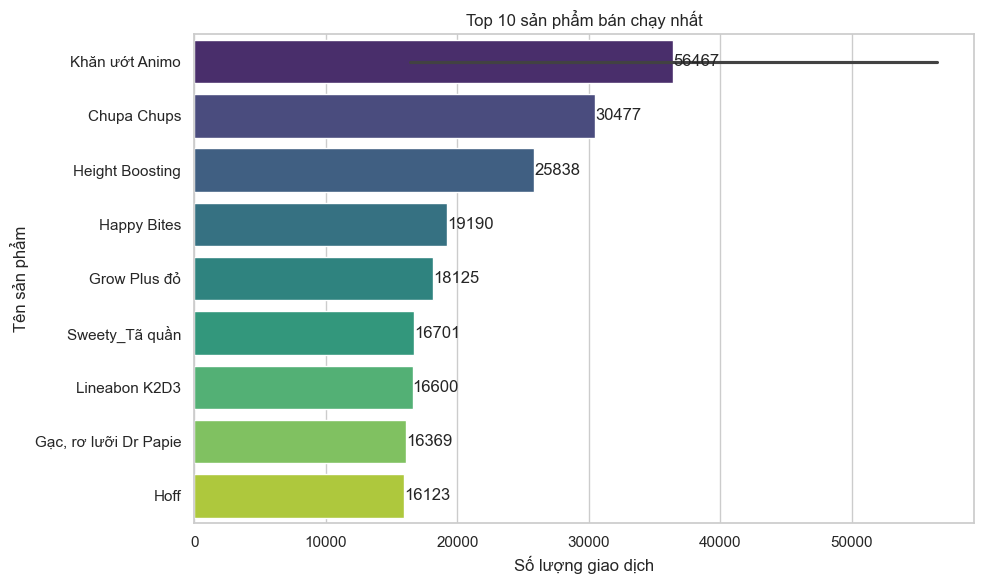

In [13]:
# Top 10 sản phẩm bán chạy nhất dựa trên tần suất giao dịch
top_items = (
    transactions
    .group_by("item_id")
    .agg(pl.count("item_id").alias("transaction_count"))
    .sort("transaction_count", descending=True)
    .head(10)
)

# Join với bảng items để lấy tên sản phẩm
top_items_with_names = top_items.join(items.select(["item_id", "category"]), on="item_id", how="left")

# Chuyển sang Pandas để vẽ
top_items_pd = top_items_with_names.to_pandas()

# Vẽ biểu đồ
plt.figure(figsize=(10, 6))
bars = sns.barplot(
    data=top_items_pd,
    y="category",
    x="transaction_count",
    palette="viridis"
)

# Hiển thị số lượng giao dịch trên từng thanh
for bar, value in zip(bars.patches, top_items_pd["transaction_count"]):
    bars.annotate(
        f"{value}", 
        (bar.get_width(), bar.get_y() + bar.get_height() / 2), 
        ha="left", 
        va="center"
    )

plt.xlabel("Số lượng giao dịch")
plt.ylabel("Tên sản phẩm")
plt.title("Top 10 sản phẩm bán chạy nhất")
plt.tight_layout()
plt.show()

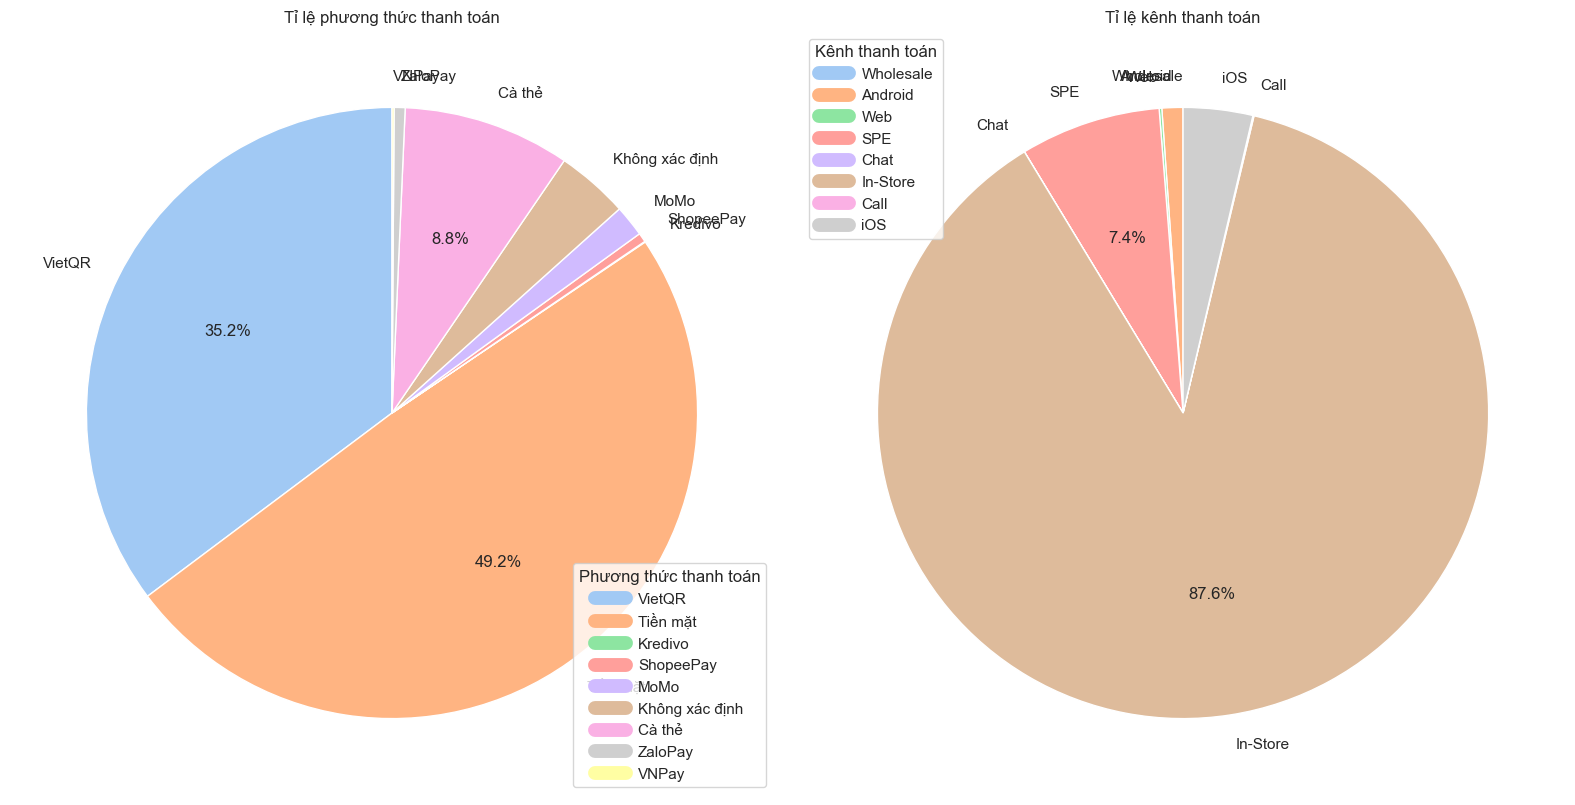

In [15]:
# Vẽ biểu đồ tròn thể hiện tỉ lệ phương thức thanh toán (payment) và kênh thanh toán (channel)

# Tính toán tỉ lệ phương thức thanh toán
payment_counts = transactions.group_by("payment").agg(pl.count("payment").alias("count")).to_pandas()

# Tính toán tỉ lệ kênh thanh toán
channel_counts = transactions.group_by("channel").agg(pl.count("channel").alias("count")).to_pandas()

# Vẽ hai biểu đồ tròn trên cùng một hình
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Biểu đồ tròn cho phương thức thanh toán
axes[0].pie(
    payment_counts["count"], 
    labels=payment_counts["payment"], 
    autopct=lambda p: f'{p:.1f}%' if p > 5 else '',  # Chỉ hiển thị tỷ lệ > 5%
    startangle=90, 
    colors=sns.color_palette("pastel")
)
axes[0].set_title("Tỉ lệ phương thức thanh toán")

# Biểu đồ tròn cho kênh thanh toán
axes[1].pie(
    channel_counts["count"], 
    labels=channel_counts["channel"], 
    autopct=lambda p: f'{p:.1f}%' if p > 5 else '',  # Chỉ hiển thị tỷ lệ > 5%
    startangle=90, 
    colors=sns.color_palette("pastel")
)
axes[1].set_title("Tỉ lệ kênh thanh toán")

# Thêm chú thích cho các tỷ lệ phần trăm
handles_payment = [plt.Line2D([0], [0], color=color, lw=10) for color in sns.color_palette("pastel")[:len(payment_counts)]]
handles_channel = [plt.Line2D([0], [0], color=color, lw=10) for color in sns.color_palette("pastel")[:len(channel_counts)]]

axes[0].legend(handles_payment, payment_counts["payment"], title="Phương thức thanh toán", loc="best")
axes[1].legend(handles_channel, channel_counts["channel"], title="Kênh thanh toán", loc="best")

plt.tight_layout()
plt.show()

C:\Users\Minh Nguyen\AppData\Local\Temp\ipykernel_3980\2262251354.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


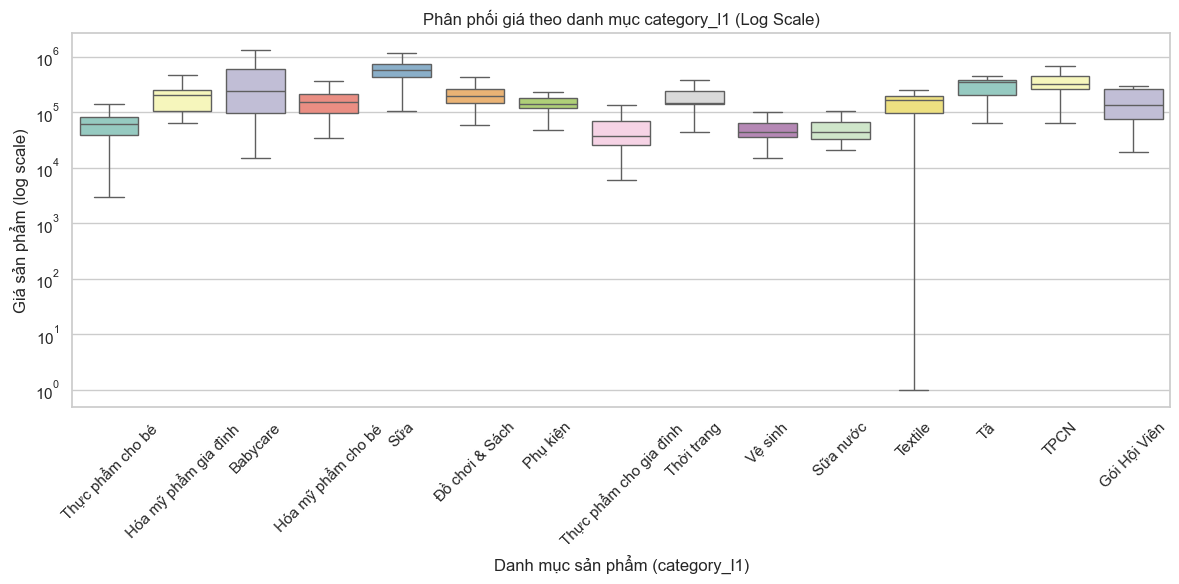

In [ ]:
df_items = items.to_pandas()

plt.figure(figsize=(12, 6))
sns.boxplot(
    data=df_items,
    x="category_l1",
    y="price",
    palette="Set3",
    showfliers=False 
)
plt.yscale("log")  
plt.xlabel("Danh mục sản phẩm (category_l1)")
plt.ylabel("Giá sản phẩm (log scale)")
plt.title("Phân phối giá theo danh mục category_l1 (Log Scale)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()